In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

## Loading the dataset

In [2]:
# Loading database connection
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data
df =  pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Description,Brand,ActualPrice,Volume,PurchasePrice,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,TotalQuantity,TotalDollars,FreightCost,GrossProfit,ProfitMargin,StockTurnover,StockToPurchaseRatio
0,8320,SHAW ROSS INT L IMP LTD,Gekkeikan Black & Gold Sake,58,12.99,750.0,9.28,16172.55,11145.42,1245.0,981.11,69127.0,624979.64,3151.92,-608807.09,-3.764447e+03,0.018010,0.025877
1,1128,BROWN-FORMAN CORP,Herradura Silver Tequila,62,36.99,750.0,28.67,41141.54,31718.94,1046.0,824.57,1006122.0,13529433.08,68601.68,-13488291.54,-3.278509e+04,0.001040,0.003041
2,1128,BROWN-FORMAN CORP,Herradura Reposado Tequila,63,38.99,750.0,30.46,36488.17,28771.03,883.0,696.25,1006122.0,13529433.08,68601.68,-13492944.91,-3.697896e+04,0.000878,0.002697
3,9165,ULTRA BEVERAGE COMPANY LLP,No. 3 London Dry Gin,72,34.99,750.0,26.11,7318.04,4843.69,196.0,154.55,1077527.0,13210613.93,68054.70,-13203295.89,-1.804212e+05,0.000182,0.000554
4,7245,PROXIMO SPIRITS INC.,Three Olives Tomato Vodka,75,14.99,750.0,10.94,134.91,104.93,9.0,7.09,682042.0,7588029.90,38994.78,-7587894.99,-5.624413e+06,0.000013,0.000018


## Exploratory Data Analysis
* Previously, we examined the various tables in the database to identify key variables, understand their relationship, and determine which ones should be included in the final analysis
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [3]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,12261.0,1.081486e+04,1.900768e+04,2.00,3.960000e+03,7.153000e+03,9.552000e+03,173357.00
Brand,12261.0,1.798907e+04,1.252850e+04,58.00,5.990000e+03,1.878800e+04,2.511700e+04,90631.00
ActualPrice,12261.0,3.864024e+01,2.061512e+02,0.00,1.099000e+01,1.599000e+01,2.999000e+01,13999.90
Volume,12261.0,8.425777e+02,6.796042e+02,0.00,7.500000e+02,7.500000e+02,7.500000e+02,20000.00
PurchasePrice,12261.0,2.648822e+01,1.561829e+02,0.00,6.890000e+00,1.065000e+01,2.013000e+01,11111.03
TotalSalesDollars,12261.0,1.281183e+04,5.401999e+04,0.00,8.910000e+00,7.837200e+02,7.454480e+03,2058278.54
TotalSalesPrice,12261.0,6.103026e+03,1.672820e+04,0.00,4.990000e+00,3.836500e+02,4.178710e+03,283398.43
TotalSalesQuantity,12261.0,9.511664e+02,3.819291e+03,0.00,1.000000e+00,3.600000e+01,4.560000e+02,134378.00
TotalExciseTax,12261.0,5.462897e+02,3.667369e+03,0.00,1.100000e-01,5.750000e+00,9.225000e+01,168760.46
TotalQuantity,12261.0,1.246762e+06,1.233287e+06,0.00,3.525260e+05,1.006122e+06,1.858260e+06,5459788.00


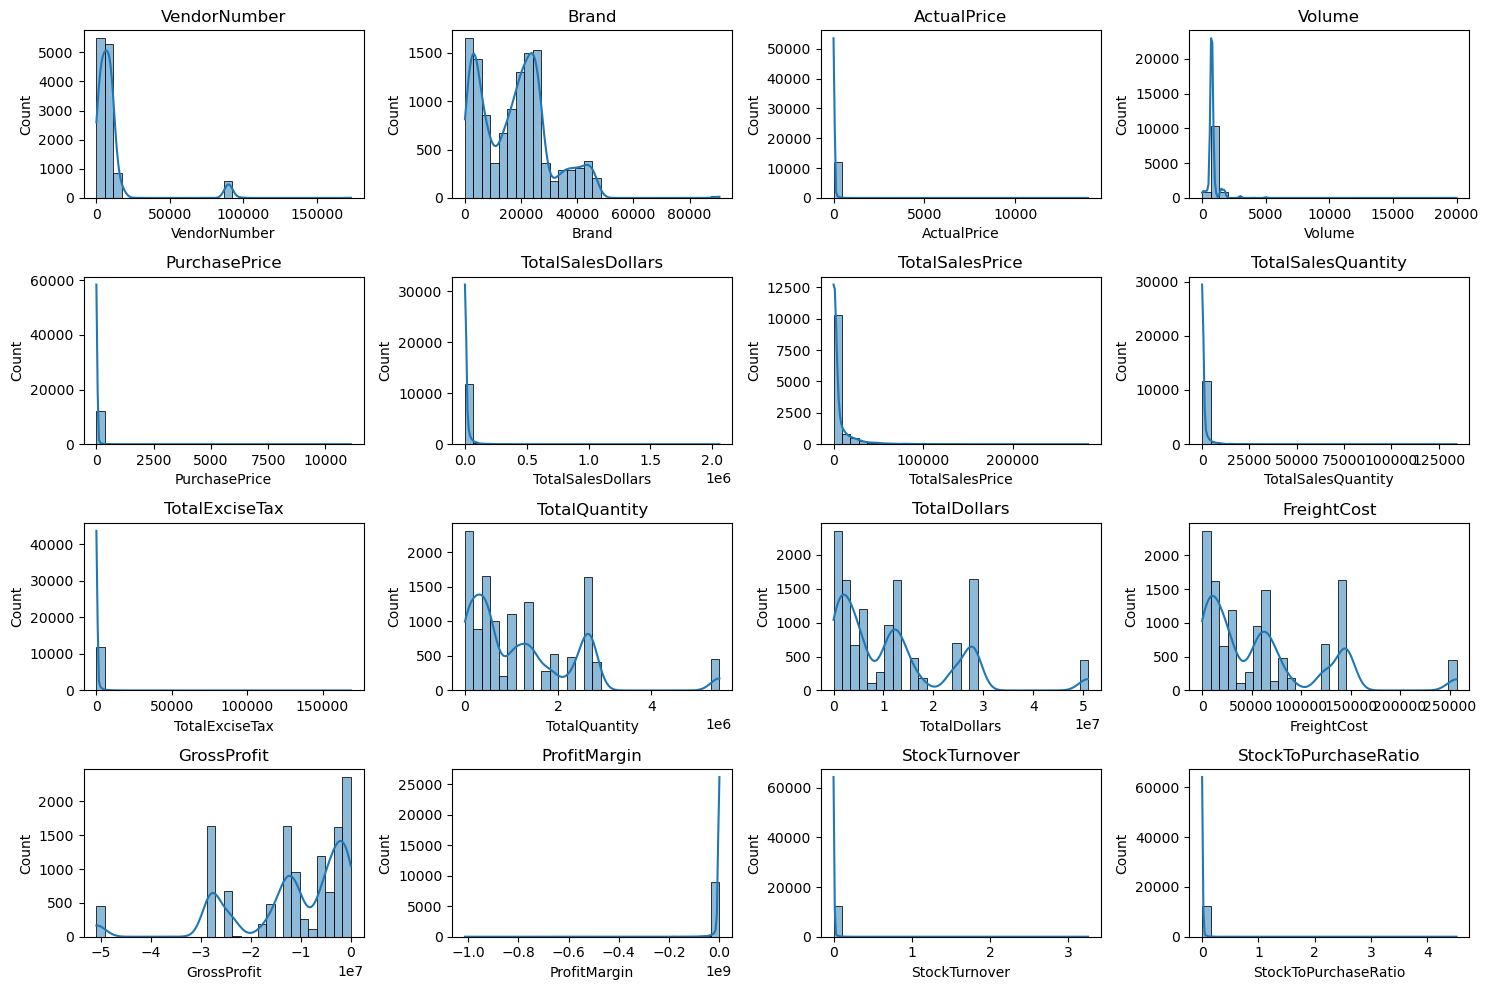

In [4]:
#Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) #Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

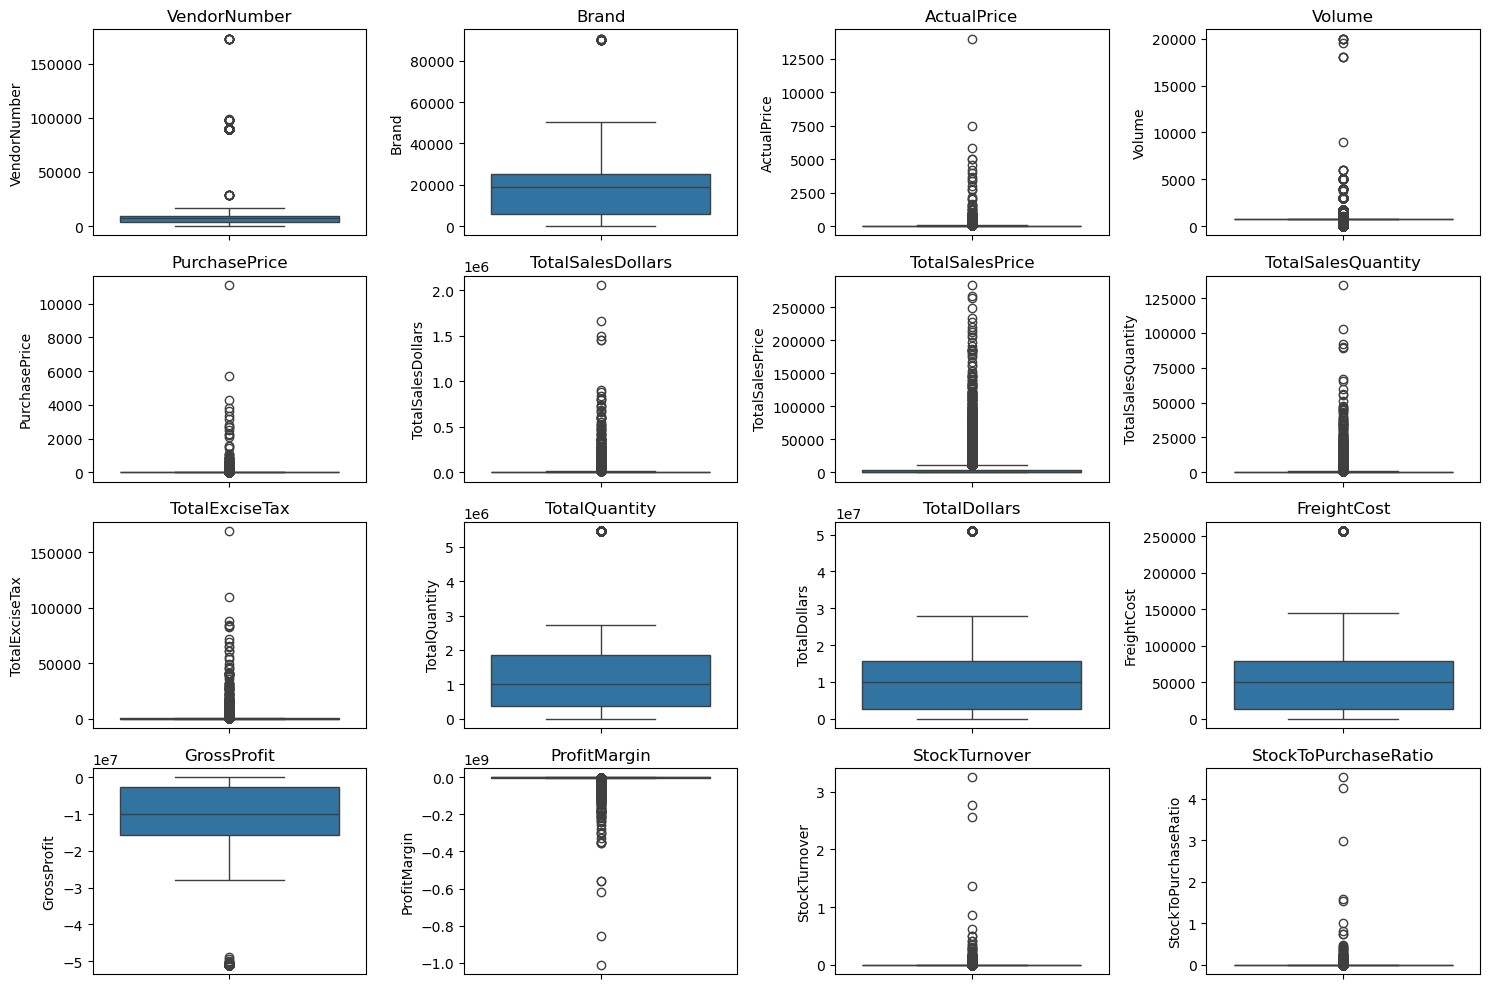

In [5]:
#Outlier Detection with Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) #Adjust grid layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Summary Statistics Insights

#### Negative & Zero Values:

* Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin: Has a minimum of -♾️, which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

#### Outlier indicated by High Standard Deviation
* Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. A value more than 1 indicates that the sold quantity for that product is higher than the purchased quantity due to either sales being fulfilled from older stock.

In [24]:
#let's filter the data by removing the inconsistencies
df = pd.read_sql_query("""SELECT * FROM
vendor_sales_summary
WHERE GrossProfit >0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

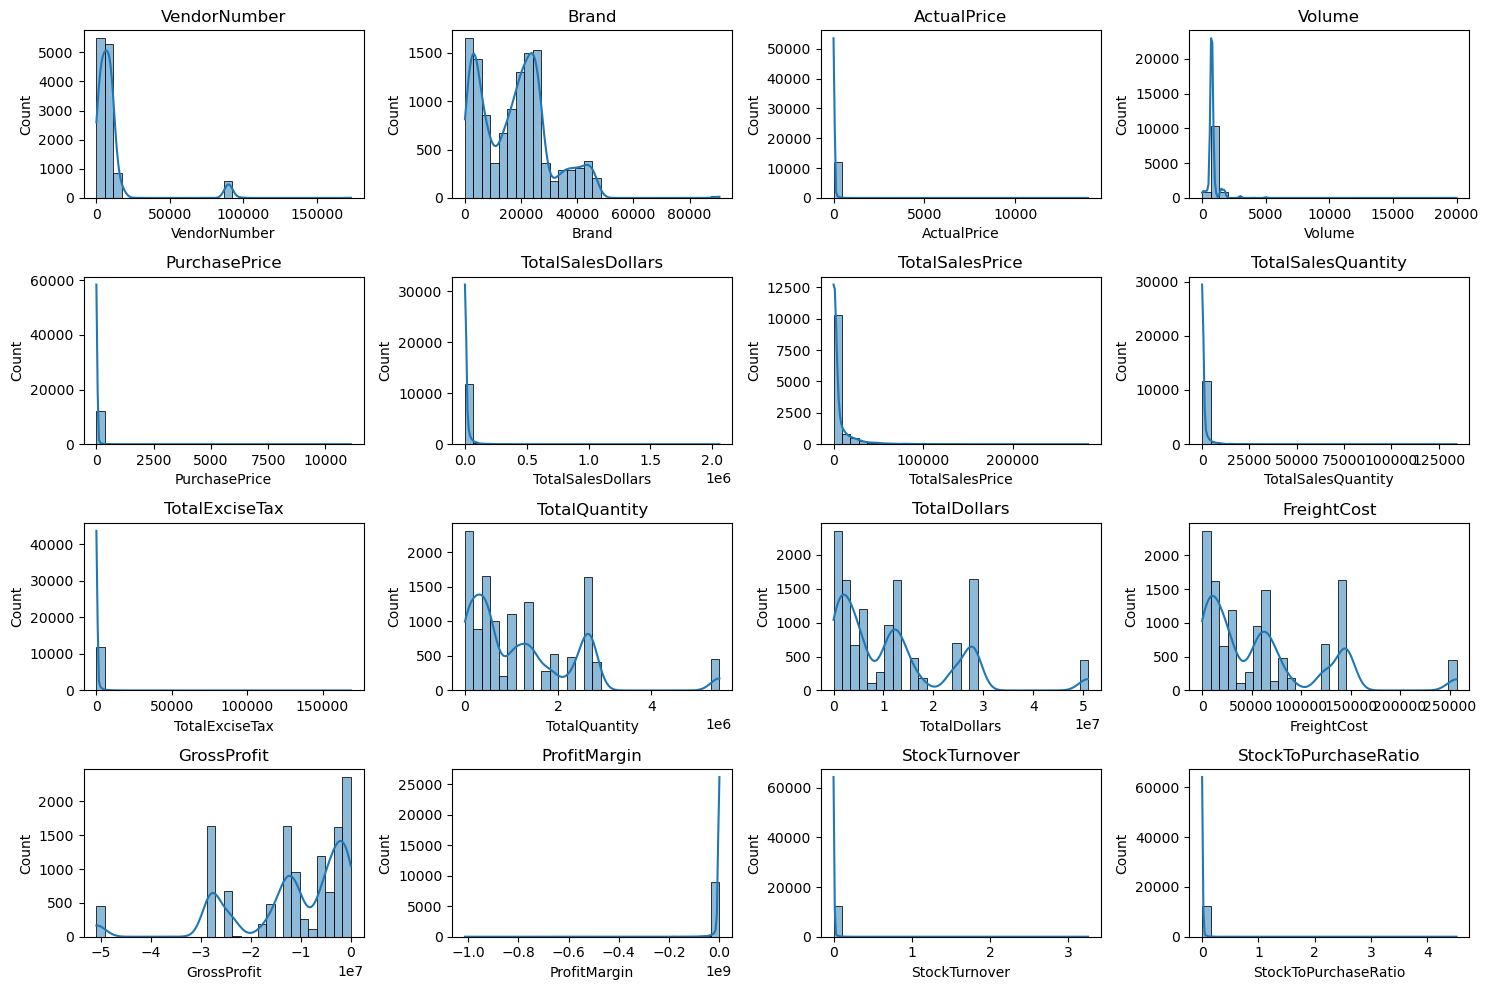

In [33]:
#Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) #Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

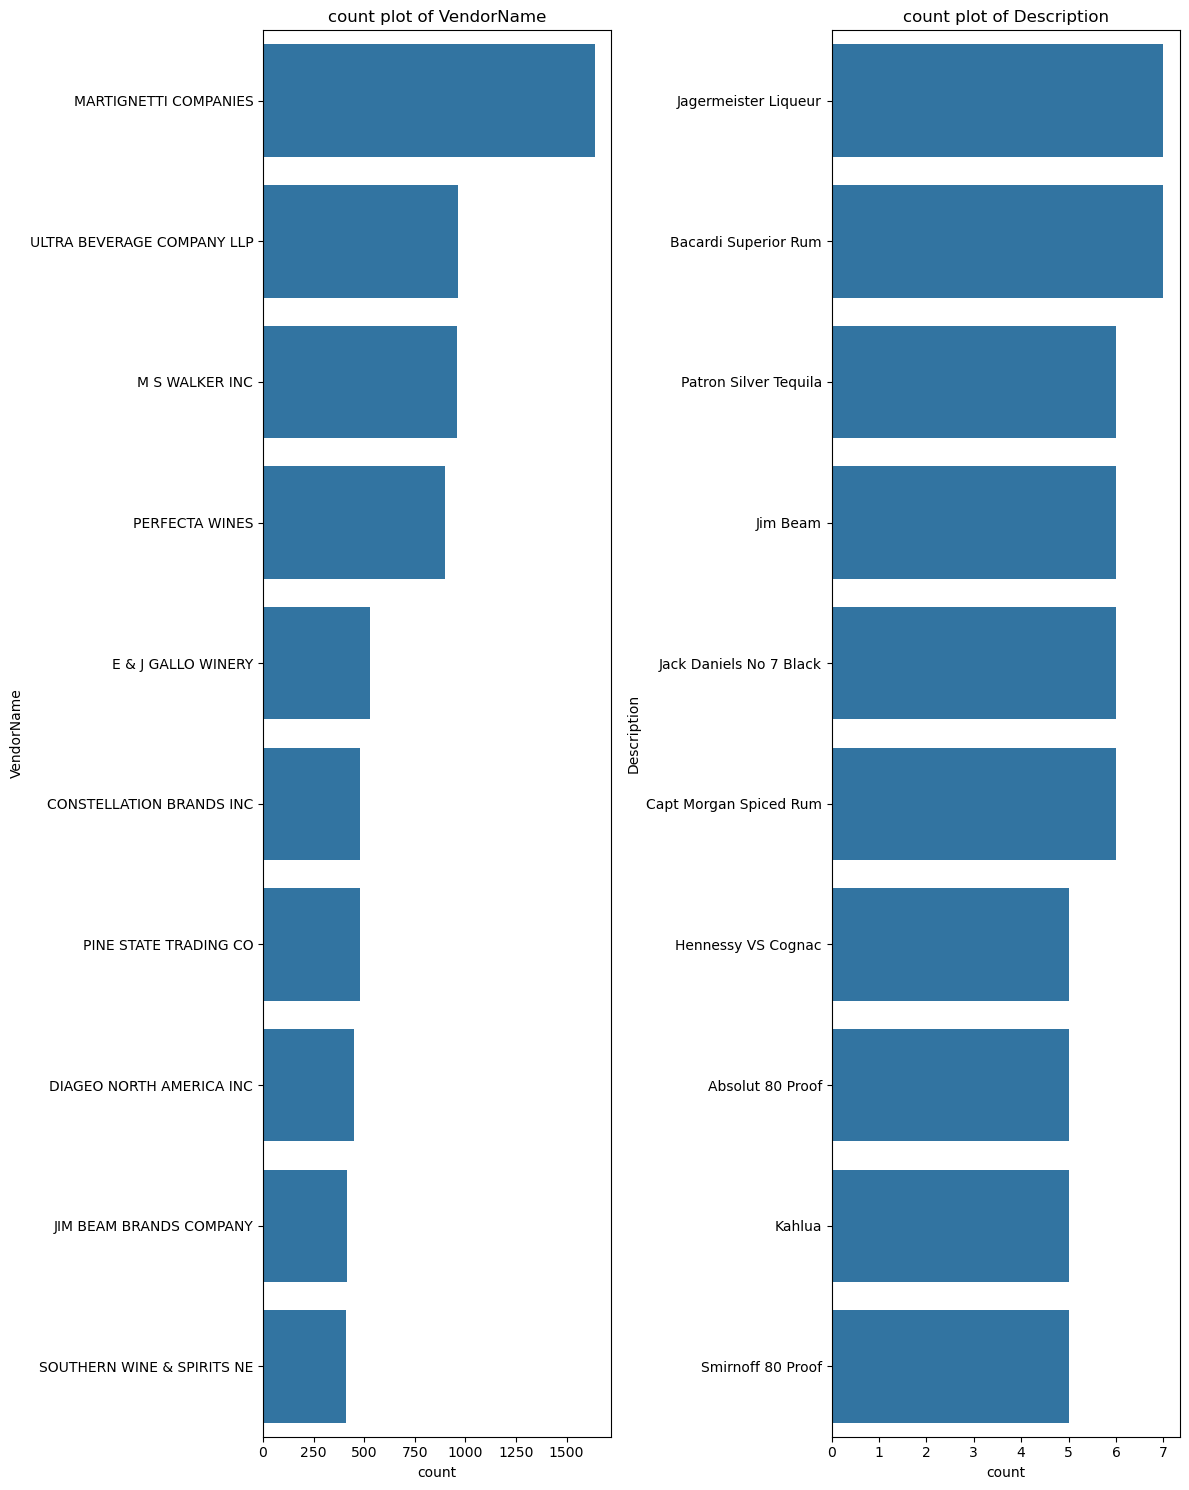

In [6]:
#Count plot for categorical columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12,15))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2, i+1) #Adjust grid layout as needed
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()

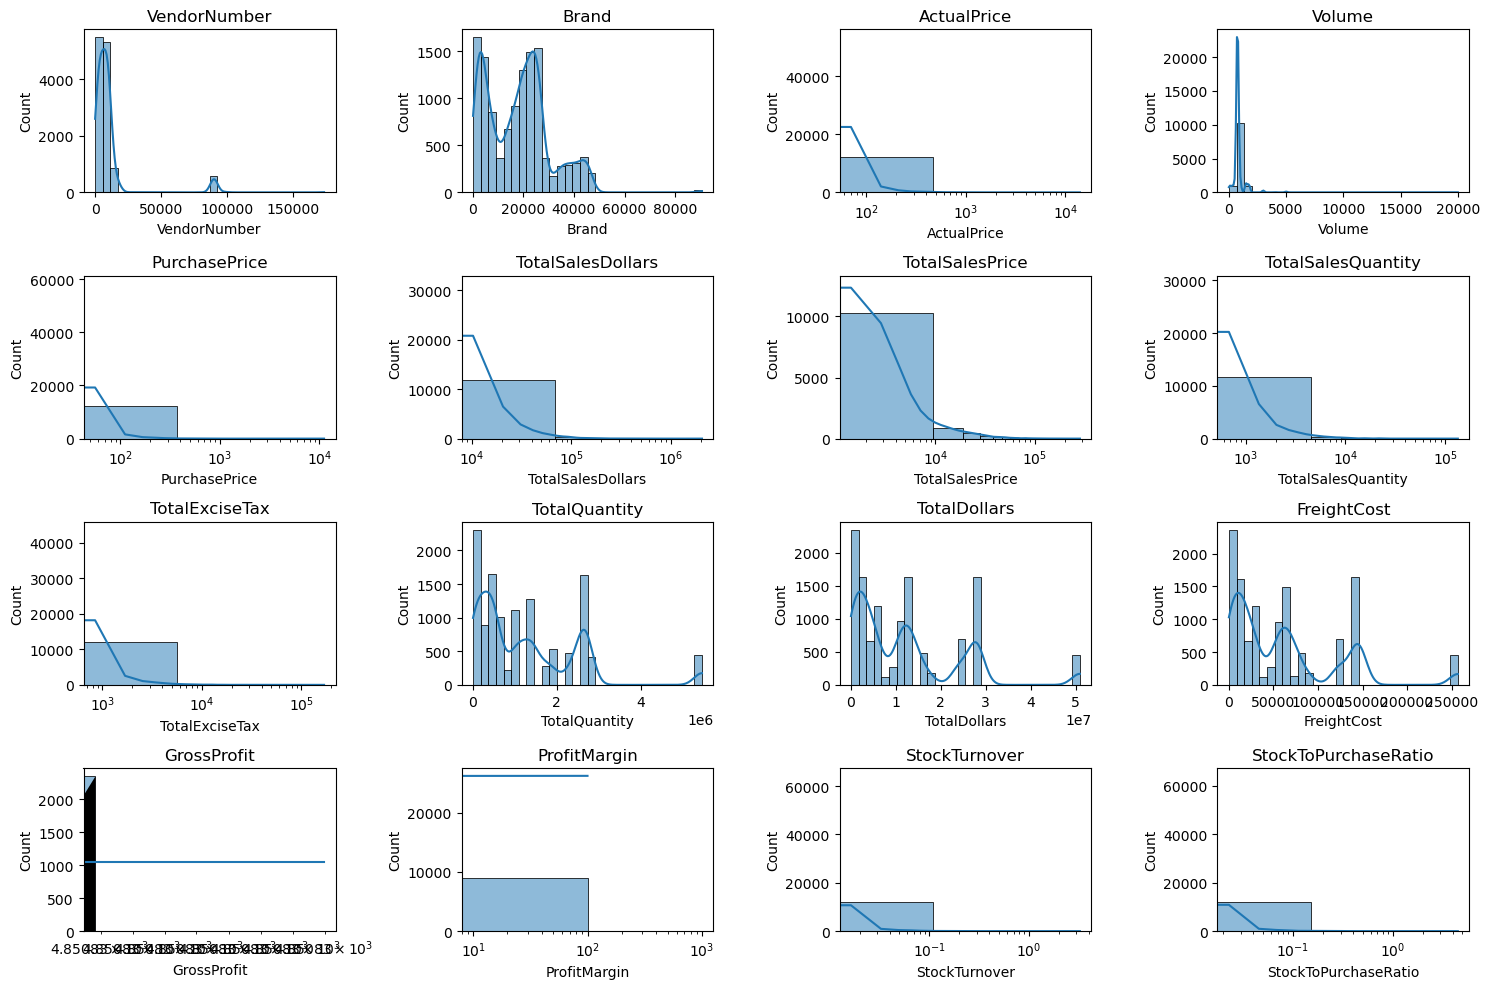

In [7]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)
    # Adding log_scale=True helps spread out skewed data
    sns.histplot(df[col], kde=True, bins=30, log_scale=(False, False)) 
    
    # Alternatively, apply log scale only if the range is huge
    if df[col].max() > 100 * df[col].median():
        plt.xscale('log')
        
    plt.title(col)
plt.tight_layout()
plt.show()

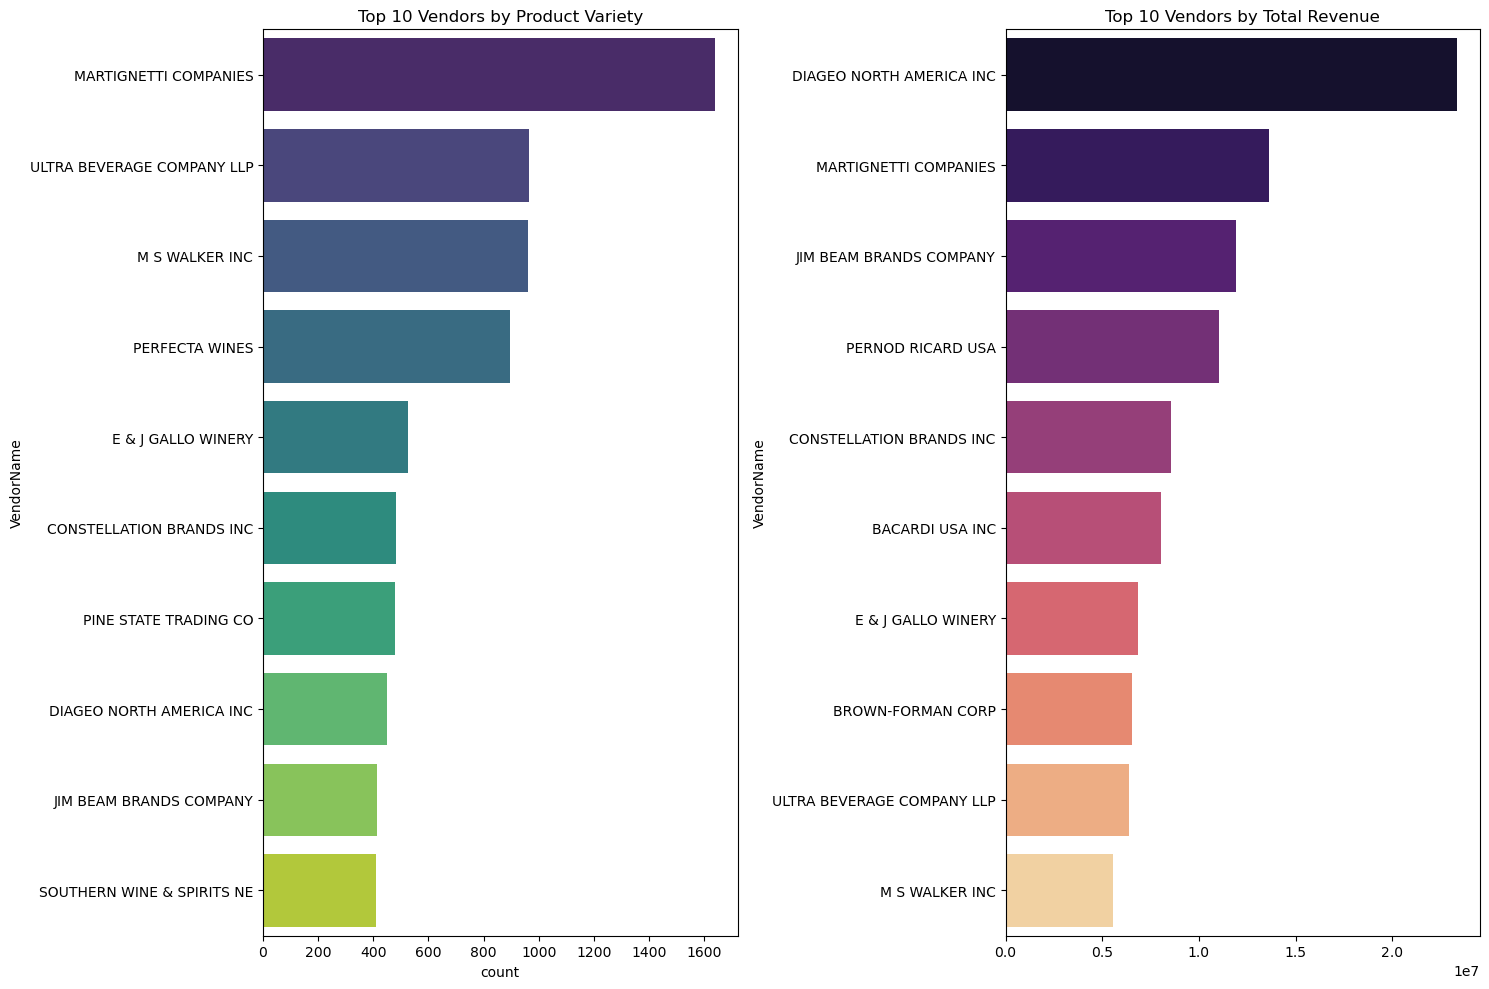

In [8]:
# Comparison: Most products vs Most Revenue
plt.figure(figsize=(15, 10))

# 1. Your Count Plot (Product Variety)
plt.subplot(1, 2, 1)
sns.countplot(y=df['VendorName'], 
              order=df['VendorName'].value_counts().index[:10], 
              palette='viridis')
plt.title("Top 10 Vendors by Product Variety")

# 2. Bar Plot (Revenue Impact)
plt.subplot(1, 2, 2)
# Summing sales by vendor to find the real heavy hitters
top_revenue_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_revenue_vendors.values, 
            y=top_revenue_vendors.index, 
            palette='magma')
plt.title("Top 10 Vendors by Total Revenue")

plt.tight_layout()
plt.show()

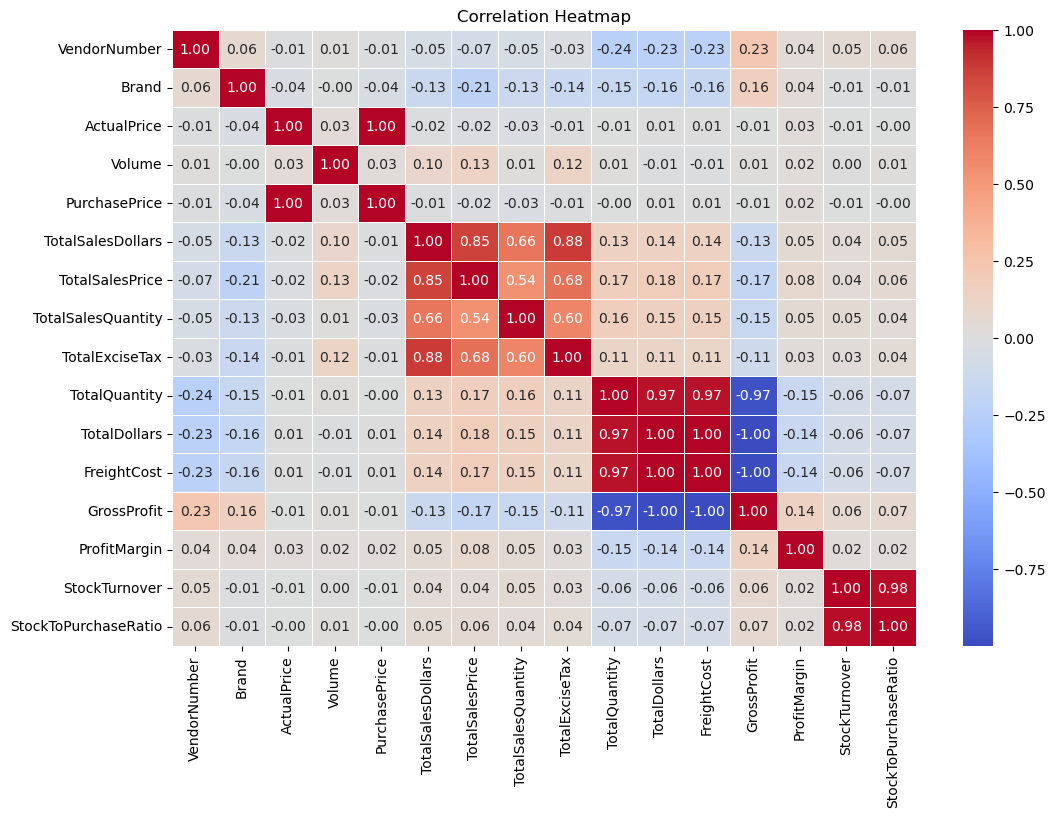

In [9]:
#Correlation Heatmap
plt.figure(figsize= (12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap = "coolwarm", linewidth = 0.5)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Insights
* PurchasePrice has weak correlation with TotalSalesDollars (-0.012)and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit
* Strong correlation between TotalPurchaseQuantity and TotalSalesQuantity (0.999), confirming efficient inventory turnover.
* Negative correlation between profit margin & TotalSalesPrice (-0.179) suggests that as sales price increases, margin decrease, possibly due to competitive pricing pressure.
* Stock turnover has weak correlation with both GrossProfit(-0.038) and ProfitMargin(-0.055), indicating that faster turnover does not necessarily result in higher profitablity.

---------------------------

## Data Analysis

#### Identify trends that needs Promotional or Pricing Adjustment which exhibits lower sales performance but higher profit margins.

In [23]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'}).reset_index()

In [24]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [25]:
low_sales_threshold

np.float64(0.0)

In [26]:
high_margin_threshold

np.float64(-35668.88743485064)

In [27]:
#Filter brands with low sales but high profit margin
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold)&
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margin:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margin:


,Description,TotalSalesDollars,ProfitMargin


### Which Vendor and Brands demonstrate the highest sales performance


In [31]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return f"{value:.2f}"


In [34]:
top_vendors.apply(lambda x: format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      23.37M
MARTIGNETTI COMPANIES         13.61M
JIM BEAM BRANDS COMPANY       11.91M
PERNOD RICARD USA             11.04M
CONSTELLATION BRANDS INC       8.57M
BACARDI USA INC                8.02M
E & J GALLO WINERY             6.83M
BROWN-FORMAN CORP              6.56M
ULTRA BEVERAGE COMPANY LLP     6.40M
M S WALKER INC                 5.57M
Name: TotalSalesDollars, dtype: object

In [28]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      23373500.31
MARTIGNETTI COMPANIES         13613073.03
JIM BEAM BRANDS COMPANY       11909180.35
PERNOD RICARD USA             11036122.95
CONSTELLATION BRANDS INC       8569834.07
BACARDI USA INC                8023979.55
E & J GALLO WINERY             6832701.59
BROWN-FORMAN CORP              6555654.04
ULTRA BEVERAGE COMPANY LLP     6404336.02
M S WALKER INC                 5567991.63
Name: TotalSalesDollars, dtype: float64

In [35]:
top_brands.apply(lambda x: format_dollars(x))

Description
Capt Morgan Spiced Rum     2.75M
Jack Daniels No 7 Black    2.69M
Tito's Handmade Vodka      2.23M
Absolut 80 Proof           2.11M
Grey Goose Vodka           1.96M
Jameson Irish Whiskey      1.87M
Ketel One Vodka            1.76M
Baileys Irish Cream        1.34M
Kahlua                     1.31M
Tanqueray                  1.18M
Name: TotalSalesDollars, dtype: object

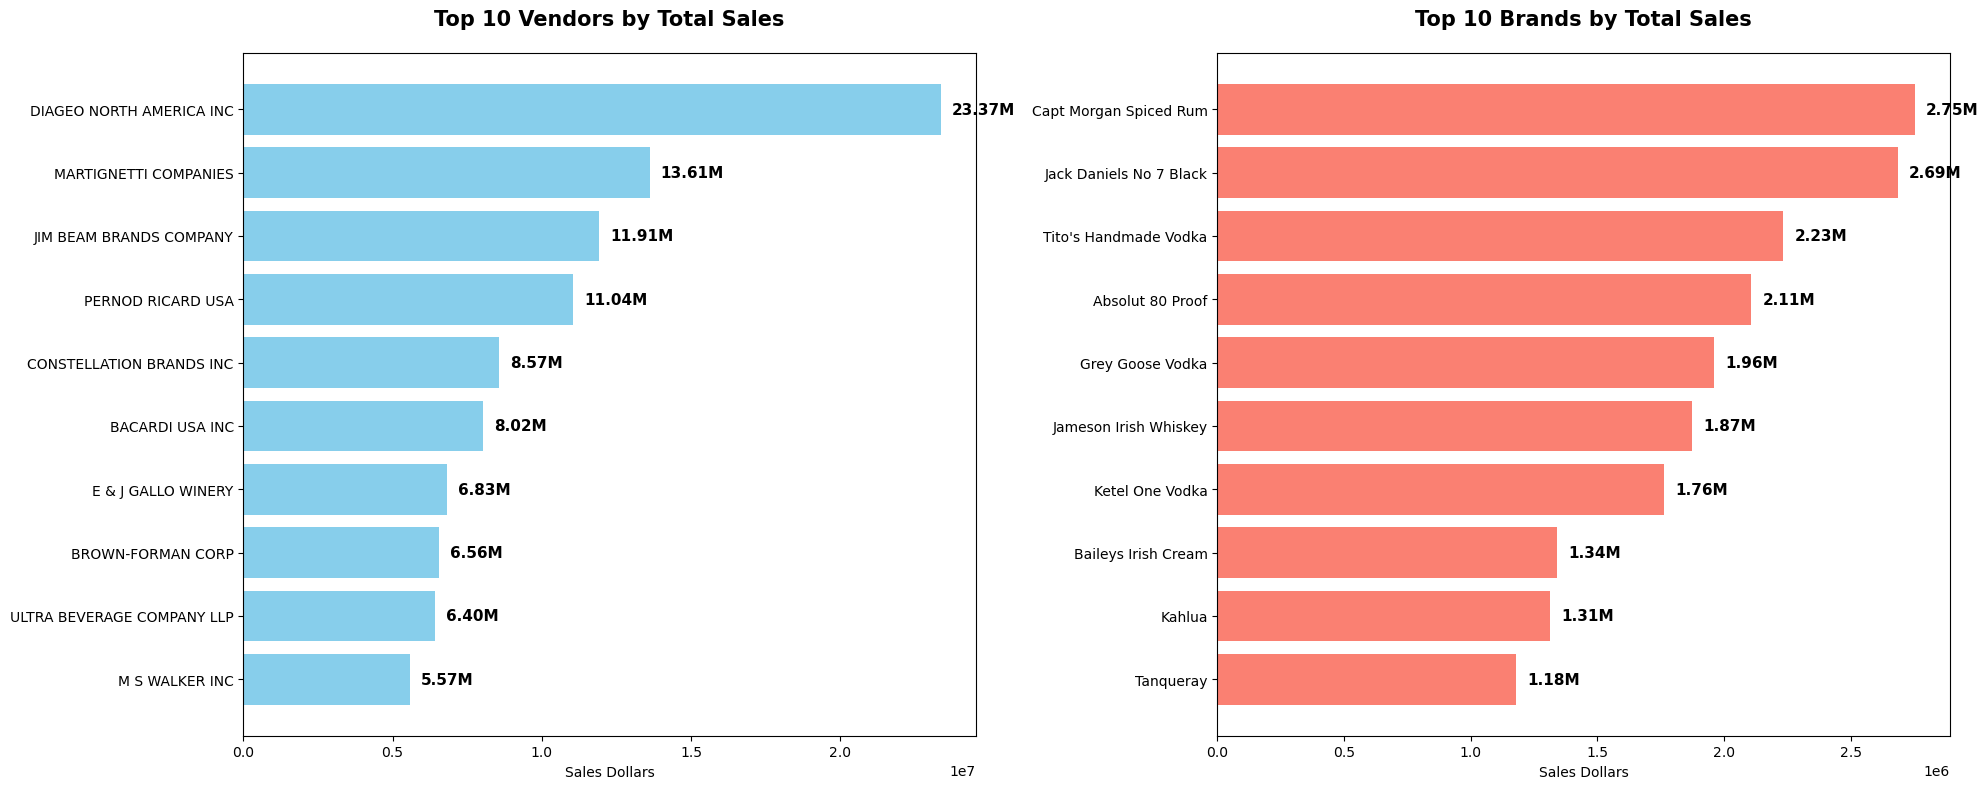

In [39]:
# Setup the visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Subplot 1: Top 10 Vendors ---
ax1 = axes[0]
bars1 = ax1.barh(top_vendors.index, top_vendors.values, color='skyblue')
ax1.set_title("Top 10 Vendors by Total Sales", fontsize=15, fontweight='bold', pad=20)
ax1.set_xlabel("Sales Dollars")
ax1.invert_yaxis()  # Put the #1 performer at the top

# Add the formatted labels to the bars
labels1 = [format_dollars(v) for v in top_vendors.values]
ax1.bar_label(bars1, labels=labels1, padding=8, fontsize=11, fontweight='bold')

# --- Subplot 2: Top 10 Brands ---
ax2 = axes[1]
bars2 = ax2.barh(top_brands.index, top_brands.values, color='salmon')
ax2.set_title("Top 10 Brands by Total Sales", fontsize=15, fontweight='bold', pad=20)
ax2.set_xlabel("Sales Dollars")
ax2.invert_yaxis()  # Put the #1 performer at the top

# Add the formatted labels to the bars
labels2 = [format_dollars(v) for v in top_brands.values]
ax2.bar_label(bars2, labels=labels2, padding=8, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Which Vendor Contribute the most total Purhcase Dollars

In [45]:
vendor_performance = df.groupby('VendorName').agg({
           'TotalDollars': 'sum',
           'GrossProfit': 'sum',
           'TotalSalesDollars':'sum'

}).reset_index()

In [47]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalDollars']/vendor_performance['TotalDollars']

In [48]:
vendor_performance

,VendorName,TotalDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,AAPER ALCOHOL & CHEMICAL CO,1.050700e+02,-1.050700e+02,0.00,1.0
1,ADAMBA IMPORTS INTL INC,2.303108e+05,-2.284617e+05,1849.02,1.0
2,ALISA CARR BEVERAGES,1.118454e+06,-1.066134e+06,52320.08,1.0
3,ALTAMAR BRANDS LLC,3.511860e+04,-2.974775e+04,5370.85,1.0
4,AMERICAN SPIRITS EXCHANGE,3.615480e+03,-3.615480e+03,0.00,1.0
...,...,...,...,...,...
128,WESTERN SPIRITS BEVERAGE CO,9.392479e+06,-9.221025e+06,171454.11,1.0
129,WHYTE & MACKAY,0.000000e+00,3.198000e+01,31.98,NaN
130,WILLIAM GRANT & SONS INC,5.066633e+08,-5.041902e+08,2473038.66,1.0
131,WINE GROUP INC,1.130607e+09,-1.127361e+09,3245562.62,1.0


In [57]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending= False), 2)

In [59]:
#Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalDollars'] = top_vendors['TotalDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)

In [60]:
top_vendors

,VendorName,TotalDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00,1.0
85,PSP WINES,4.12M,-4056490.70,68.17K,1.0
98,SOUTHERN WINE & SPIRITS NE,1526.17M,-1524037348.57,2.13M,1.0
97,SOUTHERN GLAZERS W&S OF NE,33.67M,-33665556.42,0.00,1.0
96,SMOKY QUARTZ DISTILLERY LLC,279.21K,-267384.59,11.83K,1.0
95,SILVER MOUNTAIN CIDERS,385.90,-57.37,328.53,1.0
94,SIDNEY FRANK IMPORTING CO,22.31M,-21422387.86,884.43K,1.0
93,SHAW ROSS INT L IMP LTD,23.75M,-23453657.32,295.57K,1.0
92,SEA HAGG DISTILLERY LLC,1.69M,-1647668.73,44.73K,1.0
91,SEA BREEZE CELLARS LLC,1.74M,-1698864.13,44.31K,1.0
